# All-Germany Web MLP — Nationales Preismodell (3 Kraftstoffe)

**Projekt:** HS Aalen · Sem 1 · Predictive Analytics  
**Modell:** Multi-Output MLP für alle Deutschland-Stationen, alle Kraftstoffe (Diesel, E5, E10)  
**Zweck:** Versorgt die GeoViz 3D-Karte im Web-Frontend mit nationalen 72-Stunden-Prognosen  

Ausführungsreihenfolge:
1. Alle Zellen der Reihe nach ausführen
2. Phase 3 (Load Data) lädt aus Cache wenn vorhanden, sonst ~87 GB Scan (~20-40 Min)
3. Modelle werden unter `data/models/all_germany_{fuel_type}_mlp.joblib` gespeichert

## Phase 1 — Business Understanding

### Szenario
Während Spedition-MLP und B29-Fleet-MLP spezifische Routen optimieren, liefert dieses Modell einen **nationalen Überblick** über Preisbewegungen für alle drei Kraftstofftypen.

### Business Goals
- 72-Stunden-Prognose für ~90 geografische Grid-Zellen × 3 Kraftstoffe = ~6480 Ausgaben
- MAE < 0.05 EUR/L für alle Kraftstofftypen
- Inferenzzeit < 500 ms (Web-optimiert, leichte Architektur `[128, 64]`)
- Räumliche Darstellung in der GeoViz 3D-Karte (Szenario "Nat. Modell")

### Geografisches Grid
| Parameter | Wert |
|-----------|------|
| Bounding Box | 47°N–55°N, 6°E–15°E (Deutschland) |
| Zellgröße | 0.8° × 1.0° (~89 km × 70 km) |
| Anzahl Zellen | 10 × 9 = 90 |
| Stationen gesamt | ~15.400 (alle mit gültigen Koordinaten) |
| Kraftstoffe | Diesel, E5 (Super 95), E10 |

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))  # add project root so scripts/ is importable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from dotenv import load_dotenv
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

from scripts.data_transform_all_germany import (
    AllGermanyDataLoader, get_grid_metadata,
    GRID_ROWS, GRID_COLS, GRID_LAT_START, GRID_LAT_STEP, GRID_LON_START, GRID_LON_STEP,
)

load_dotenv('../.env')

MODELS_DIR = Path('..') / 'data' / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

FUEL_TYPES    = ['diesel', 'e5', 'e10']
FUEL_COLORS   = {'diesel': '#f59e0b', 'e5': '#3b82f6', 'e10': '#8b5cf6'}
FORECAST_HORIZON = 72

print('Setup complete. Modelle werden gespeichert unter:', MODELS_DIR.resolve())

Setup complete. Modelle werden gespeichert unter: /home/jawasch/Documents/HS_Aalen/Sem1/PredictiveAnalytics/Projekt/Test_Spritpreise/data/models


## Phase 2 — Data Understanding

Grid cells total: 90


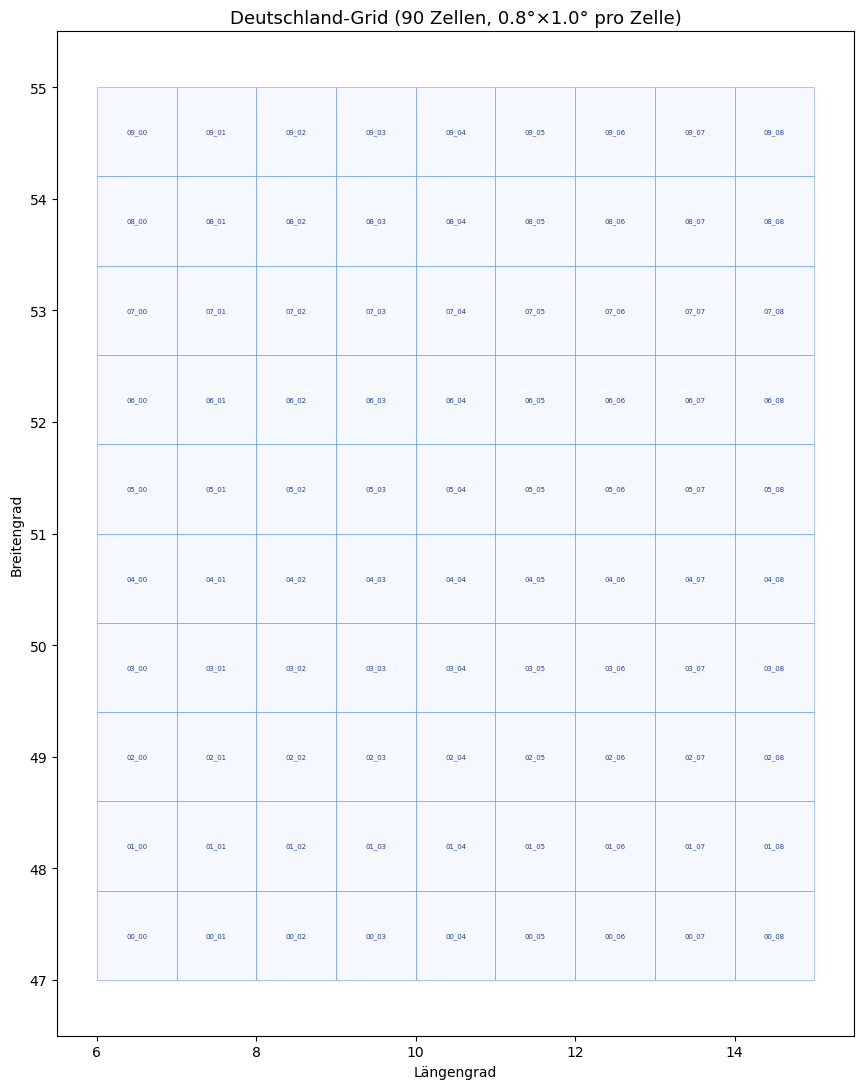

In [2]:
# 2a — Grid visualisation
grid_meta = get_grid_metadata()
print(f'Grid cells total: {len(grid_meta)}')

fig, ax = plt.subplots(figsize=(9, 11))
for _, cell_row in grid_meta.iterrows():
    rect = plt.Rectangle(
        (cell_row.lon_min, cell_row.lat_min), GRID_LON_STEP, GRID_LAT_STEP,
        linewidth=0.5, edgecolor='#3b82f6', facecolor='#eff6ff', alpha=0.6
    )
    ax.add_patch(rect)
    ax.text(cell_row.lon, cell_row.lat, cell_row.cell_id[-5:],
            ha='center', va='center', fontsize=5, color='#1e40af')
ax.set_xlim(5.5, 15.5)
ax.set_ylim(46.5, 55.5)
ax.set_aspect(1.4)
ax.set_xlabel('Längengrad')
ax.set_ylabel('Breitengrad')
ax.set_title('Deutschland-Grid (90 Zellen, 0.8°×1.0° pro Zelle)', fontsize=13)
plt.tight_layout()
plt.show()

## Phase 3 — Data Loading & Preparation

**Quick Mode (Standard, empfohlen):**
- Verwendet die vorhandenen Parquet-Dateien (B29 + Spedition, ~4 MB)
- `quick_mode=True` — kein 87-GB-Scan, < 200 MB RAM, < 30 s

**RAM-Strategie:** Die Modelle werden sequenziell trainiert — ein Kraftstoff nach dem anderen.
Jede Iteration hält nur die Daten für einen Kraftstoff im RAM (~1-2 GB Peak).
Zwischen den Iterationen wird der Speicher explizit freigegeben (`del` + `gc.collect()`).

In [3]:
# 3a — Load base data (all fuel types; small in-memory combined DataFrame)
import gc

loader = AllGermanyDataLoader(
    fuel_types=FUEL_TYPES,
    forecast_horizon=FORECAST_HORIZON,
    quick_mode=True,   # set False for full 90-cell Germany model (requires 87 GB raw CSVs + ≥ 8 GB RAM)
    debug=True,
)

# Load diesel-only first to show train/val/test sizes
X_demo, y_demo = loader.load(single_fuel='diesel')
X_tr_demo, X_v_demo, X_te_demo, y_tr_demo, y_v_demo, y_te_demo = loader.train_val_test_split(X_demo, y_demo)
print(f'Feature matrix (diesel): X={X_demo.shape}, y={y_demo.shape}')
print(f'Train: {len(X_tr_demo):,} | Val: {len(X_v_demo):,} | Test: {len(X_te_demo):,}')
del X_demo, y_demo, X_v_demo, X_te_demo, y_v_demo, y_te_demo; gc.collect()

[AllGermany] quick_mode=True — using existing processed parquets (no raw-CSV scan). Pass quick_mode=False for the full 90-cell dataset.
[quick_load] B29 parquet: (104751, 4), last=2026-05-20 23:00:00
[quick_load] Spedition parquet: (104748, 5), last=2026-05-20 20:00:00
[quick_load] Combined DataFrame: (104751, 27), 2014-06-08 → 2026-05-20
  Train :  66,136 rows  (2014-06-15 → 2021-12-31)
  Val   :  17,520 rows  (2021-12-31 → 2023-12-31)
  Test  :  20,852 rows  (2023-12-31 → 2026-05-17)
Feature matrix (diesel): X=(104508, 519), y=(104508, 648)
Train: 66,136 | Val: 17,520 | Test: 20,852


20

In [4]:
# 3b — Note: Feature scaling is done inside the per-fuel training loop (Phase 4b)
# to avoid holding 3 copies of scaled data in RAM simultaneously.
# Each fuel type gets its own StandardScaler fitted on that fuel's training data.
print('Scaling will be done per fuel type in Phase 4b.')

Scaling will be done per fuel type in Phase 4b.


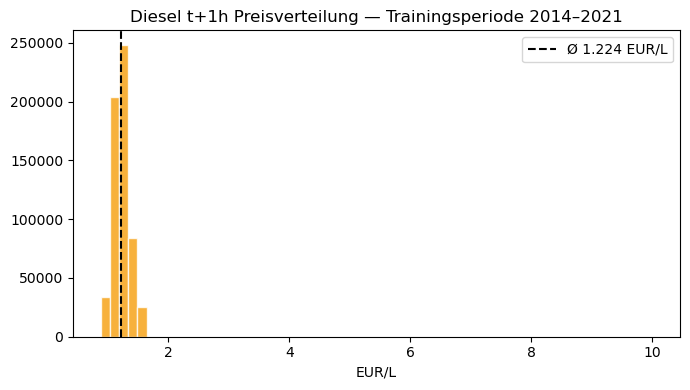

8

In [5]:
# 3c — Price distribution (training period, diesel shown as example)
# y_tr_demo contains all diesel target columns (9 locations × 72 horizons)
t1_cols = [c for c in y_tr_demo.columns if '_t+1h' in c]
prices = y_tr_demo[t1_cols].values.flatten()
prices = prices[~__import__('numpy').isnan(prices)]

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(prices, bins=60, color='#f59e0b', alpha=0.8, edgecolor='white')
ax.axvline(prices.mean(), color='black', linestyle='--', lw=1.5,
            label=f'Ø {prices.mean():.3f} EUR/L')
ax.set_title('Diesel t+1h Preisverteilung — Trainingsperiode 2014–2021')
ax.set_xlabel('EUR/L')
ax.legend()
plt.tight_layout()
plt.show()
del y_tr_demo; gc.collect()

## Phase 4 — Modelling

Ein separates leichtgewichtiges MLP pro Kraftstoff:
- **Architektur:** `[128, 64]` (Web-optimiert)
- **Eingaben:** alle Features (Lags, Rolling, Trend, Zyklik)
- **Ausgaben:** N_Zellen × 72 Horizonte
- **Vergleich:** auch `[64]` und `[256, 128]` werden getestet

In [6]:
# 4a — Architecture comparison (diesel only, single_fuel to save RAM)
ARCHITECTURES = [(64,), (128, 64), (256, 128)]

X_d, y_d = loader.load(single_fuel='diesel')
X_tr_d, X_v_d, _, y_tr_d, y_v_d, _ = loader.train_val_test_split(X_d, y_d)
sc_X_d = StandardScaler().fit(X_tr_d)
sc_y_d = StandardScaler().fit(y_tr_d)
X_tr_ds = sc_X_d.transform(X_tr_d)
X_v_ds  = sc_X_d.transform(X_v_d)

for arch in ARCHITECTURES:
    m = MLPRegressor(hidden_layer_sizes=arch, activation='relu', solver='adam',
                     max_iter=300, early_stopping=True, validation_fraction=0.1,
                     n_iter_no_change=10, random_state=42, verbose=False)
    m.fit(X_tr_ds, sc_y_d.transform(y_tr_d))
    y_pred = sc_y_d.inverse_transform(m.predict(X_v_ds))
    mae = float(__import__('numpy').nanmean(__import__('numpy').abs(y_pred - y_v_d.values)))
    print(f'  diesel {str(arch):15s}: Val MAE={mae:.5f}  iters={m.n_iter_}')

del X_d, y_d, X_tr_d, X_v_d, y_tr_d, y_v_d, X_tr_ds, X_v_ds, sc_X_d, sc_y_d
gc.collect()
print('Architecture comparison done — RAM released.')

[AllGermany] quick_mode=True — using existing processed parquets (no raw-CSV scan). Pass quick_mode=False for the full 90-cell dataset.
[quick_load] B29 parquet: (104751, 4), last=2026-05-20 23:00:00
[quick_load] Spedition parquet: (104748, 5), last=2026-05-20 20:00:00
[quick_load] Combined DataFrame: (104751, 27), 2014-06-08 → 2026-05-20
  Train :  66,136 rows  (2014-06-15 → 2021-12-31)
  Val   :  17,520 rows  (2021-12-31 → 2023-12-31)
  Test  :  20,852 rows  (2023-12-31 → 2026-05-17)
  diesel (64,)          : Val MAE=0.03132  iters=74
  diesel (128, 64)      : Val MAE=0.03429  iters=89
  diesel (256, 128)     : Val MAE=0.03654  iters=82
Architecture comparison done — RAM released.


In [7]:
# 4b — Train one fuel type at a time
#  Peak RAM per iteration: ~1.1 GB  |  Total time: ~15-25 min
#  X (features) is the same for all fuel types — computed once and reused.

import gc

# Pre-compute X once (features include all fuel types as predictors)
print('Pre-computing feature matrix X (done once for all fuels) ...')
X_all, _ = loader.load(single_fuel='diesel')  # X is identical regardless of single_fuel
X_tr_all, X_v_all, X_te_all, _, _, _ = loader.train_val_test_split(X_all, _)
sc_X_shared = StandardScaler().fit(X_tr_all)
X_tr_s_shared = sc_X_shared.transform(X_tr_all)
X_v_s_shared  = sc_X_shared.transform(X_v_all)
print(f'  X_train scaled: {X_tr_s_shared.shape}  ({X_tr_s_shared.nbytes / 1e6:.0f} MB)')

for ft in FUEL_TYPES:
    print(f'\n=== Training {ft.upper()} ===')

    # 1. Load ONLY the target columns for this fuel type
    _, y_ft = loader.load(single_fuel=ft)
    _, _, _, y_tr, y_v, y_te = loader.train_val_test_split(X_all, y_ft)
    print(f'  y_train: {y_tr.shape}  ({y_tr.memory_usage(deep=True).sum() / 1e6:.0f} MB)')

    # 2. Scale targets
    sc_y = StandardScaler().fit(y_tr)

    # 3. Train (uses pre-computed X_tr_s_shared)
    model = MLPRegressor(
        hidden_layer_sizes=(128, 64), activation='relu', solver='adam',
        max_iter=500, early_stopping=True, validation_fraction=0.1,
        n_iter_no_change=15, random_state=42, verbose=True,
    )
    model.fit(X_tr_s_shared, sc_y.transform(y_tr))
    print(f'  Done: {model.n_iter_} iterations.')

    # 4. Quick val-MAE check
    y_pred_v = sc_y.inverse_transform(model.predict(X_v_s_shared))
    val_mae = float(np.nanmean(np.abs(y_pred_v - y_v.values)))
    print(f'  Val MAE: {val_mae:.5f} EUR/L')

    # 5. Save artifact
    artifact = {
        'model':            model,
        'scaler_X':         sc_X_shared,
        'scaler_y':         sc_y,
        'feature_columns':  list(X_all.columns),
        'target_columns':   list(y_tr.columns),
        'fuel_type':        ft,
        'forecast_horizon': FORECAST_HORIZON,
        'architecture':     '(128, 64)',
        'val_mae':          round(val_mae, 5),
    }
    path = MODELS_DIR / f'all_germany_{ft}_mlp.joblib'
    joblib.dump(artifact, path)
    print(f'  Saved: {path.name}  ({path.stat().st_size // 1024} KB)')

    # 6. Release target data and model (keep shared X)
    del y_ft, y_tr, y_v, y_te, y_pred_v, model, sc_y, artifact
    gc.collect()
    print(f'  RAM released (X shared still cached).')

# Release shared X after all fuels done
del X_all, X_tr_all, X_v_all, X_te_all, X_tr_s_shared, X_v_s_shared, sc_X_shared
gc.collect()
print('\nAll 3 models saved! Shared X released.')

Pre-computing feature matrix X (done once for all fuels) ...
[AllGermany] quick_mode=True — using existing processed parquets (no raw-CSV scan). Pass quick_mode=False for the full 90-cell dataset.
[quick_load] B29 parquet: (104751, 4), last=2026-05-20 23:00:00
[quick_load] Spedition parquet: (104748, 5), last=2026-05-20 20:00:00
[quick_load] Combined DataFrame: (104751, 27), 2014-06-08 → 2026-05-20
  Train :  66,136 rows  (2014-06-15 → 2021-12-31)
  Val   :  17,520 rows  (2021-12-31 → 2023-12-31)
  Test  :  20,852 rows  (2023-12-31 → 2026-05-17)
  X_train scaled: (66136, 519)  (275 MB)

=== Training DIESEL ===
[AllGermany] quick_mode=True — using existing processed parquets (no raw-CSV scan). Pass quick_mode=False for the full 90-cell dataset.
[quick_load] B29 parquet: (104751, 4), last=2026-05-20 23:00:00
[quick_load] Spedition parquet: (104748, 5), last=2026-05-20 20:00:00
[quick_load] Combined DataFrame: (104751, 27), 2014-06-08 → 2026-05-20
  Train :  66,136 rows  (2014-06-15 → 202

In [8]:
# 4c — Artifacts are saved inside the loop above.
# Verify:
for ft in FUEL_TYPES:
    p = MODELS_DIR / f'all_germany_{ft}_mlp.joblib'
    status = f'{p.stat().st_size // 1024} KB' if p.exists() else 'MISSING'
    print(f'  all_germany_{ft}_mlp.joblib : {status}')

  all_germany_diesel_mlp.joblib : 2838 KB
  all_germany_e5_mlp.joblib : 2830 KB
  all_germany_e10_mlp.joblib : 2833 KB


## Phase 5 — Evaluation

[AllGermany] quick_mode=True — using existing processed parquets (no raw-CSV scan). Pass quick_mode=False for the full 90-cell dataset.
[quick_load] B29 parquet: (104751, 4), last=2026-05-20 23:00:00
[quick_load] Spedition parquet: (104748, 5), last=2026-05-20 20:00:00
[quick_load] Combined DataFrame: (104751, 27), 2014-06-08 → 2026-05-20
  Train :  66,136 rows  (2014-06-15 → 2021-12-31)
  Val   :  17,520 rows  (2021-12-31 → 2023-12-31)
  Test  :  20,852 rows  (2023-12-31 → 2026-05-17)
DIESEL : Ø MAE=0.0289  Baseline=0.4527  Δ=93.6%
[AllGermany] quick_mode=True — using existing processed parquets (no raw-CSV scan). Pass quick_mode=False for the full 90-cell dataset.
[quick_load] B29 parquet: (104751, 4), last=2026-05-20 23:00:00
[quick_load] Spedition parquet: (104748, 5), last=2026-05-20 20:00:00
[quick_load] Combined DataFrame: (104751, 27), 2014-06-08 → 2026-05-20
  Train :  66,136 rows  (2014-06-15 → 2021-12-31)
  Val   :  17,520 rows  (2021-12-31 → 2023-12-31)
  Test  :  20,852 ro

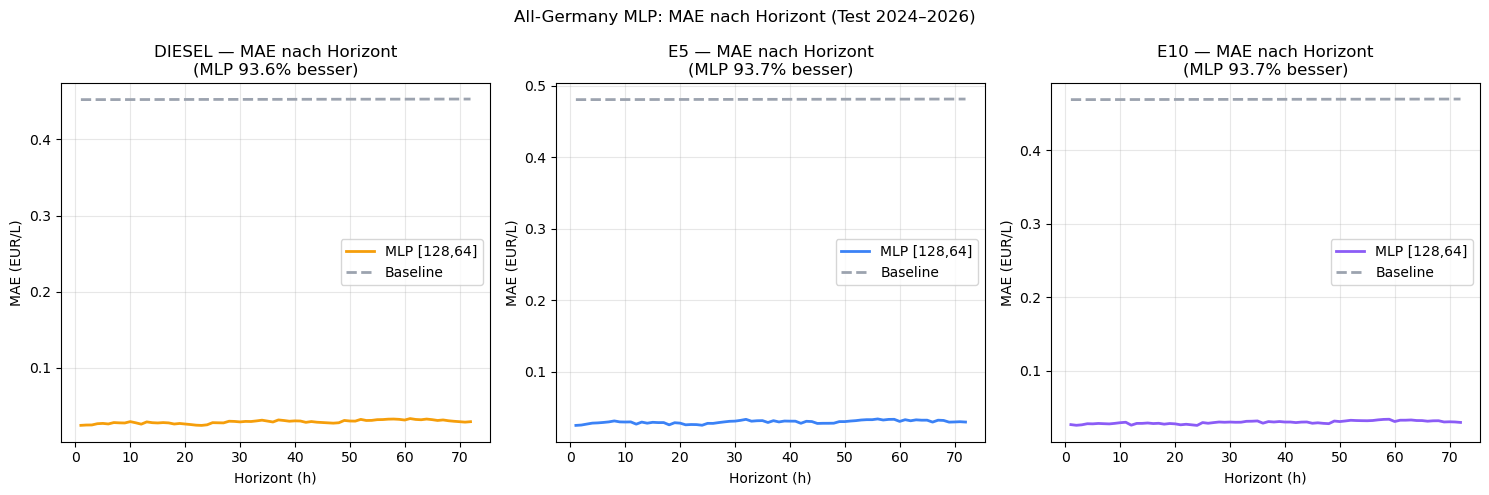

In [9]:
# 5a — MAE by horizon: load each artifact separately to stay within RAM budget
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, ft in enumerate(FUEL_TYPES):
    path = MODELS_DIR / f'all_germany_{ft}_mlp.joblib'
    if not path.exists():
        axes[i].set_title(f'{ft.upper()} — kein Modell')
        continue

    art = joblib.load(path)
    sc_X, sc_y, model = art['scaler_X'], art['scaler_y'], art['model']

    X_ft, y_ft = loader.load(single_fuel=ft)
    X_tr, _, X_te, y_tr, _, y_te = loader.train_val_test_split(X_ft, y_ft)

    y_pred  = sc_y.inverse_transform(model.predict(sc_X.transform(X_te)))
    base    = DummyRegressor(strategy='mean').fit(sc_X.transform(X_tr), sc_y.transform(y_tr))
    y_base  = sc_y.inverse_transform(base.predict(sc_X.transform(X_te)))
    y_true  = y_te.values
    ft_cols = list(y_te.columns)

    mae_mlp, mae_base = [], []
    for h in range(1, FORECAST_HORIZON + 1):
        h_idx = [j for j, c in enumerate(ft_cols) if c.endswith(f'_t+{h}h')]
        if h_idx:
            mae_mlp.append(np.nanmean(np.abs(y_pred[:, h_idx] - y_true[:, h_idx])))
            mae_base.append(np.nanmean(np.abs(y_base[:, h_idx] - y_true[:, h_idx])))

    imp = (1 - np.mean(mae_mlp) / np.mean(mae_base)) * 100
    axes[i].plot(range(1, len(mae_mlp)+1), mae_mlp,  color=FUEL_COLORS[ft], lw=2, label='MLP [128,64]')
    axes[i].plot(range(1, len(mae_base)+1), mae_base, color='#9ca3af', lw=2, ls='--', label='Baseline')
    axes[i].set_title(f'{ft.upper()} — MAE nach Horizont\n(MLP {imp:.1f}% besser)')
    axes[i].set_xlabel('Horizont (h)')
    axes[i].set_ylabel('MAE (EUR/L)')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
    print(f'{ft.upper():7s}: Ø MAE={np.mean(mae_mlp):.4f}  Baseline={np.mean(mae_base):.4f}  Δ={imp:.1f}%')

    del X_ft, y_ft, X_tr, X_te, y_tr, y_te, y_pred, y_base, art, model
    gc.collect()

plt.suptitle('All-Germany MLP: MAE nach Horizont (Test 2024–2026)', fontsize=12)
plt.tight_layout()
plt.show()

[AllGermany] quick_mode=True — using existing processed parquets (no raw-CSV scan). Pass quick_mode=False for the full 90-cell dataset.
[quick_load] B29 parquet: (104751, 4), last=2026-05-20 23:00:00
[quick_load] Spedition parquet: (104748, 5), last=2026-05-20 20:00:00
[quick_load] Combined DataFrame: (104751, 27), 2014-06-08 → 2026-05-20
  Train :  66,136 rows  (2014-06-15 → 2021-12-31)
  Val   :  17,520 rows  (2021-12-31 → 2023-12-31)
  Test  :  20,852 rows  (2023-12-31 → 2026-05-17)


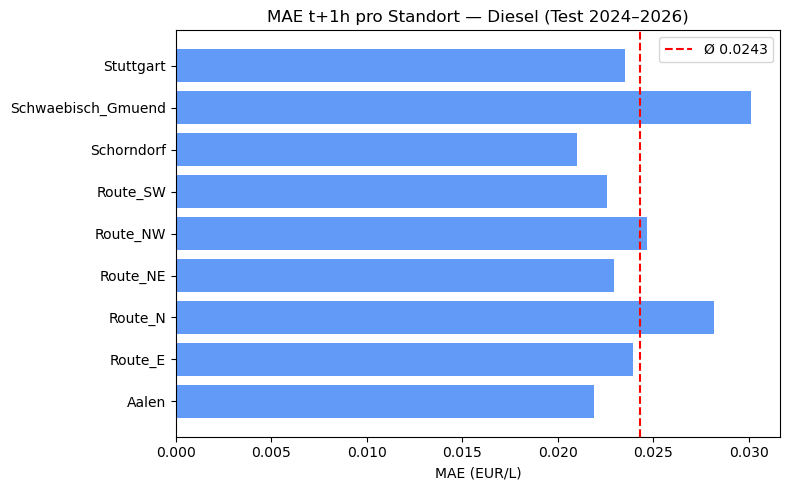

In [10]:
# 5b — Geographic MAE heatmap (Diesel t+1h)
ft = 'diesel'
path = MODELS_DIR / f'all_germany_{ft}_mlp.joblib'
if path.exists():
    art = joblib.load(path)
    X_ft, y_ft = loader.load(single_fuel=ft)
    _, _, X_te, _, _, y_te = loader.train_val_test_split(X_ft, y_ft)

    y_pred_d = art['scaler_y'].inverse_transform(art['model'].predict(art['scaler_X'].transform(X_te)))
    y_true_d = y_te.values
    ft_cols  = list(y_te.columns)

    cell_mae = {}
    for j, col in enumerate(ft_cols):
        if '_t+1h' in col:
            loc = col.replace(f'{ft}_', '').replace('_t+1h', '')
            cell_mae[loc] = np.nanmean(np.abs(y_pred_d[:, j] - y_true_d[:, j]))

    fig, ax = plt.subplots(figsize=(8, 5))
    locs = sorted(cell_mae.keys())
    maes = [cell_mae[l] for l in locs]
    bars = ax.barh(locs, maes, color='#3b82f6', alpha=0.8)
    ax.axvline(np.mean(maes), color='red', linestyle='--', label=f'Ø {np.mean(maes):.4f}')
    ax.set_xlabel('MAE (EUR/L)')
    ax.set_title('MAE t+1h pro Standort — Diesel (Test 2024–2026)')
    ax.legend()
    plt.tight_layout()
    plt.show()

    del X_ft, y_ft, X_te, y_te, y_pred_d, y_true_d, art
    gc.collect()
else:
    print(f'{ft} model not found — run Phase 4b first.')

## Phase 6 — Deployment / Web-Integration

### Modelle gespeichert
```
data/models/all_germany_diesel_mlp.joblib
data/models/all_germany_e5_mlp.joblib
data/models/all_germany_e10_mlp.joblib
```

### Wie das Backend die Modelle nutzt
Nach Neustart des Docker-Backends lädt `ml_service.py` die Modelle automatisch:
1. `ml_service.predict_all_germany('diesel')` → Prognosen für alle ~N_Zellen Grid-Zellen
2. Backend-Antwort: Array mit `{id, label, lat, lng, prices: [{timestamp, price}]}`
3. Frontend: GeoViz → Szenario **"Nat. Modell"** zeigt die Grid-Zellen als 3D-Spalten

### Modell-Update-Zyklus
```
neue Rohdaten → loader.load(refresh=True) → Notebook erneut ausführen → artifacts gespeichert → Backend neu starten
```

In [11]:
# 6 — Inference time benchmark
import time

print('=== Inferenz-Benchmark ===')
for ft in FUEL_TYPES:
    path = MODELS_DIR / f'all_germany_{ft}_mlp.joblib'
    if not path.exists():
        print(f'{ft.upper():7s}: Modell nicht gefunden')
        continue
    art = joblib.load(path)

    X_ft, _ = loader.load(single_fuel=ft)
    x_last  = art['scaler_X'].transform(X_ft.iloc[[-1]])

    times = []
    for _ in range(20):
        t0 = time.perf_counter()
        y_p = art['scaler_y'].inverse_transform(art['model'].predict(x_last))[0]
        times.append((time.perf_counter() - t0) * 1000)

    n_tgts = len(art['target_columns'])
    t1_mean = float(np.nanmean([y_p[j] for j, c in enumerate(art['target_columns']) if '_t+1h' in c]))
    print(f'{ft.upper():7s}: {n_tgts} Ausgaben  |  '
          f'{np.mean(times):.1f} ms (±{np.std(times):.1f} ms)  |  Ø t+1h = {t1_mean:.3f} EUR/L')

    del X_ft, art; gc.collect()

print(f'\nModelle: {MODELS_DIR.resolve()}')
print('GeoViz-Szenario "Nat. Modell" nach Backend-Neustart verfügbar.')

=== Inferenz-Benchmark ===
[AllGermany] quick_mode=True — using existing processed parquets (no raw-CSV scan). Pass quick_mode=False for the full 90-cell dataset.
[quick_load] B29 parquet: (104751, 4), last=2026-05-20 23:00:00
[quick_load] Spedition parquet: (104748, 5), last=2026-05-20 20:00:00
[quick_load] Combined DataFrame: (104751, 27), 2014-06-08 → 2026-05-20
DIESEL : 648 Ausgaben  |  0.2 ms (±0.1 ms)  |  Ø t+1h = 1.929 EUR/L
[AllGermany] quick_mode=True — using existing processed parquets (no raw-CSV scan). Pass quick_mode=False for the full 90-cell dataset.
[quick_load] B29 parquet: (104751, 4), last=2026-05-20 23:00:00
[quick_load] Spedition parquet: (104748, 5), last=2026-05-20 20:00:00
[quick_load] Combined DataFrame: (104751, 27), 2014-06-08 → 2026-05-20
E5     : 648 Ausgaben  |  0.2 ms (±0.1 ms)  |  Ø t+1h = 2.058 EUR/L
[AllGermany] quick_mode=True — using existing processed parquets (no raw-CSV scan). Pass quick_mode=False for the full 90-cell dataset.
[quick_load] B29 pa